This notebook investigates results for different scenarios showing both the GNN estimates and cIM estimates.

In [1]:
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

import sim_ranking as sr
import ml_tools as mlt

In [2]:
n_obs_sites = 10

In [3]:
wdata = "/Users/claudy/dev/work/data"

results_dir = "/Users/claudy/dev/work/data/sim_ranking/results/gnn/1120_1125_cv_nzgmdb4p0_4_8_maxDist20_maxSites10_500epochs_sigmoid_nonlinearity_withAllTanh_2x31layers_L2Reg0p001_NoZx_DOut0p5"

In [4]:
# Injected Parameters
results_dir = "/Users/claudy/dev/work/data/sim_ranking/results/gnn/simple/1126_1423_cv_test_4_8_250Epochs_multiHead5"
wdata = "/Users/claudy/dev/work/data"


In [5]:
wdata = Path(wdata)
gnn_results_dir = Path(results_dir)
cim_results_dir = gnn_results_dir / "cim_results"
warnings.simplefilter(action='ignore', category=FutureWarning)

run_config = sr.ml.gnn_gm.RunConfig.from_yaml(gnn_results_dir / "run_config.yaml")

**Result Directory:** `{python} str(gnn_results_dir)`

In [6]:
# Load the combined validation results
gnn_val_results = pd.read_parquet(gnn_results_dir / "val_results.parquet").sort_index()

cim_val_results = None
if (cim_results_dir / "val_results.parquet").exists():
    cim_val_results = pd.read_parquet(cim_results_dir / "val_results.parquet").sort_index()

In [7]:
# Load observed data to get metadata
run_config = sr.ml.gnn_gm.RunConfig.from_yaml(gnn_results_dir / "run_config.yaml")
nzgmdb_ffp = wdata / run_config.rel_obs_data_ffp
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)

In [8]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(obs_data.sites, obs_data.site_df)

In [9]:
# Load the empirical GMM predictions
emp_gmm_params = sr.data.load_emp_gmm_params( wdata / "sim_ranking/emp_gm_params/nzgmdb_v4p0" / "emp_gm_params.parquet" )
emp_gmm_pSA_mean_keys = [f"pSA_{cur_period}_mean" for cur_period in sr.constants.PERIODS]
emp_gmm_pSA_std_keys = [f"pSA_{cur_period}_std_Total" for cur_period in sr.constants.PERIODS]

In [10]:
def get_obs_sites(event: str, int_site: str, gnn_val_results: pd.DataFrame, dist_matrix: pd.DataFrame, n_obs_sites: int = 5):
    cur_id = f"{event}_{int_site}"
    obs_sites = (
        dist_matrix.loc[cur_site]
        .loc[gnn_val_results.loc[cur_id].obs_sites.astype(str)]
        .sort_values()
        .index.values.astype(str)
    )[:n_obs_sites]
    
    return obs_sites

def exp_formatter(y, pos):
    return f'{np.exp(y):.4f}'
    # return f"{np.exp(y):.2e}"

def plot_gnn_cim(ax: plt.Axes, cur_id: str, gnn_results: pd.DataFrame, cim_results: pd.DataFrame = None, emp_gmm_params: pd.DataFrame = None, log_values: bool = False):
    
    # Empirical GMM
    if emp_gmm_params is not None:
        cur_emp_gmm_mean = emp_gmm_params.loc[cur_id, emp_gmm_pSA_mean_keys].values.astype(float)
        cur_emp_gmm_std = emp_gmm_params.loc[cur_id, emp_gmm_pSA_std_keys].values.astype(float)
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean if log_values else np.exp(cur_emp_gmm_mean), label="Empirical GMM", c="gray")
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean + cur_emp_gmm_std if log_values else np.exp(cur_emp_gmm_mean + cur_emp_gmm_std), c="gray", linestyle="--")
        ax.plot(sr.constants.PERIODS, cur_emp_gmm_mean - cur_emp_gmm_std if log_values else np.exp(cur_emp_gmm_mean - cur_emp_gmm_std), c="gray", linestyle="--")
    
    # CIM
    if cim_results is not None:
        cur_cim_mean = cim_results.loc[cur_id, sr.constants.CIM_PRED_PSA_KEYS].values.astype(float)
        cur_cim_std = cim_results.loc[cur_id, sr.constants.CIM_PRED_STD_PSA_KEYS].values.astype(float)
        ax.plot(sr.constants.PERIODS, cur_cim_mean if log_values else np.exp(cur_cim_mean), label="cIM", c="g")
        ax.plot(sr.constants.PERIODS, cur_cim_mean + cur_cim_std if log_values else np.exp(cur_cim_mean + cur_cim_std), c="g", linestyle="--")
        ax.plot(sr.constants.PERIODS, cur_cim_mean - cur_cim_std if log_values else np.exp(cur_cim_mean - cur_cim_std), c="g", linestyle="--")
        
    # GNN
    cur_gnn_mean = gnn_results.loc[cur_id, sr.constants.GNN_PRED_PSA_KEYS].values.astype(float)
    cur_gnn_std = gnn_results.loc[cur_id, sr.constants.GNN_PRED_STD_PSA_KEYS].values.astype(float)
    ax.plot(sr.constants.PERIODS, cur_gnn_mean if log_values else np.exp(cur_gnn_mean), label="GNN", c="b")
    ax.plot(sr.constants.PERIODS, cur_gnn_mean + cur_gnn_std if log_values else np.exp(cur_gnn_mean + cur_gnn_std), c="b", linestyle="--")
    ax.plot(sr.constants.PERIODS,  cur_gnn_mean - cur_gnn_std if log_values else np.exp(cur_gnn_mean - cur_gnn_std), c="b", linestyle="--")
        
    # Observed
    obs_values = gnn_results.loc[cur_id, sr.constants.PSA_KEYS].values.astype(float) 
    ax.plot(sr.constants.PERIODS, 
        obs_values if log_values else np.exp(obs_values), 
        label="Observed", c="r")
    
    
        
    ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    
    if log_values:
        ax.yaxis.set_major_formatter(FuncFormatter(exp_formatter))
        
    ax.set_xscale("log")
    ax.set_xlim(0.01, 10)
    ax.set_xlabel("Period (s)")
    
    # Get smallest/largest y-values
    min_y = min([min(line.get_ydata()) for line in ax.get_lines()])
    max_y = max([max(line.get_ydata()) for line in ax.get_lines()])
    if log_values:
        return np.exp(min_y), np.exp(max_y)
    return min_y, max_y
    
def plot_obs_sites(ax: plt.Axes, event: str, int_site: str, obs_sites: np.ndarray[str], obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, log_values: bool = False):
    # cur_id = f"{event}_{int_site}"

    cur_obs_sites_dist = dist_matrix.loc[int_site].loc[obs_sites]
    cur_obs_data = obs_data.get_event_data(event, obs_sites)
    
    for int_site in obs_sites:
        cur_values = cur_obs_data.loc[int_site, sr.constants.PSA_KEYS].values.astype(float)
        ax.plot(sr.constants.PERIODS, np.log(cur_values) if log_values else cur_values, label=f"{int_site}, {cur_obs_sites_dist[int_site]:.2f} km")
    
    ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")    
    
    if log_values:
        ax.yaxis.set_major_formatter(FuncFormatter(exp_formatter))
        
    ax.set_xscale("log")
    ax.set_xlim(0.01, 10)
    ax.set_xlabel("Period (s)")
    
    # Get smallest/largest y-values
    min_y = min([min(line.get_ydata()) for line in ax.get_lines()])
    max_y = max([max(line.get_ydata()) for line in ax.get_lines()])
    if log_values:
        return np.exp(min_y), np.exp(max_y)
    return min_y, max_y

In [11]:
def create_4plot(event: str, int_site: str, obs_sites: np.ndarray[str], gnn_val_results: pd.DataFrame, cim_val_results: pd.DataFrame, obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, emp_gmm_params: pd.DataFrame = None):
    cur_id = f"{event}_{int_site}"
    
    fig, (ax1, ax2, ax3, ax4) = mlt.plotting.get_fig_axes(4, 2, 2, ind_figsize=(8, 6))
    
    min_y1, max_y1 = plot_gnn_cim(ax1, cur_id, gnn_val_results, cim_val_results, emp_gmm_params)
    ax1.legend()
    
    min_y2, max_y2 = plot_gnn_cim(ax2, cur_id, gnn_val_results, cim_val_results, log_values=True, emp_gmm_params=emp_gmm_params)
    ax2.set_ylim(None, np.log(ax1.get_ylim()[1]))
    
    min_y3, max_y3 = plot_obs_sites(ax3, event, int_site, obs_sites, obs_data, dist_matrix)
    ax3.legend()
    # ax3.set_ylim(None, np.log(ax1.get_ylim()[1]))
    
    min_y4, max_y4 = plot_obs_sites(ax4, event, int_site, obs_sites, obs_data, dist_matrix, log_values=True)
    
    # y-axis limits
    min_y = min(min_y1, min_y2, min_y3, min_y4)
    max_y = max(max_y1, max_y2, max_y3, max_y4)
    
    ax1.set_ylim(min_y, max_y)
    ax2.set_ylim(np.log(min_y), np.log(max_y))
    ax3.set_ylim(min_y, max_y)
    ax4.set_ylim(np.log(min_y), np.log(max_y))
    
    fig.tight_layout()

In [12]:
def create_2plot_log(event: str, int_site: str, obs_sites: np.ndarray[str], gnn_val_results: pd.DataFrame, cim_val_results: pd.DataFrame, obs_data: sr.ObservedData, dist_matrix: pd.DataFrame, emp_gmm_params: pd.DataFrame = None):
    cur_id = f"{event}_{int_site}"
    
    fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, ind_figsize=(8, 6))
    
    min_y2, max_y2 = plot_gnn_cim(ax1, cur_id, gnn_val_results, cim_val_results, log_values=True, emp_gmm_params=emp_gmm_params)
    ax1.legend()
    
    min_y4, max_y4 = plot_obs_sites(ax2, event, int_site, obs_sites, obs_data, dist_matrix, log_values=True)
    ax2.legend()
    
    # y-axis limits
    min_y = min(min_y2, min_y4)
    max_y = max(max_y2, max_y4)
    ax1.set_ylim(np.log(min_y), np.log(max_y))
    ax2.set_ylim(np.log(min_y), np.log(max_y))
    
    fig.tight_layout()

In [13]:
def get_site_info_df(event: str, int_site: str, obs_sites: np.ndarray[str], obs_data: sr.ObservedData, dist_matrix: pd.DataFrame):
    site_cols = ["rrup", "vs30", "z1p0", "z2p5", "tsite"]
    site_info_sites = [int_site] + cur_obs_sites.tolist()
    site_info_records = mlt.array_utils.numpy_str_join("_", event, site_info_sites)
    
    site_info_df = obs_data.record_df.loc[site_info_records, site_cols].copy()
    site_info_df["site_int_distance"] = (
        dist_matrix.loc[int_site].loc[site_info_sites].values
    )
    
    return site_info_df

### 2016p858000 - HSSS

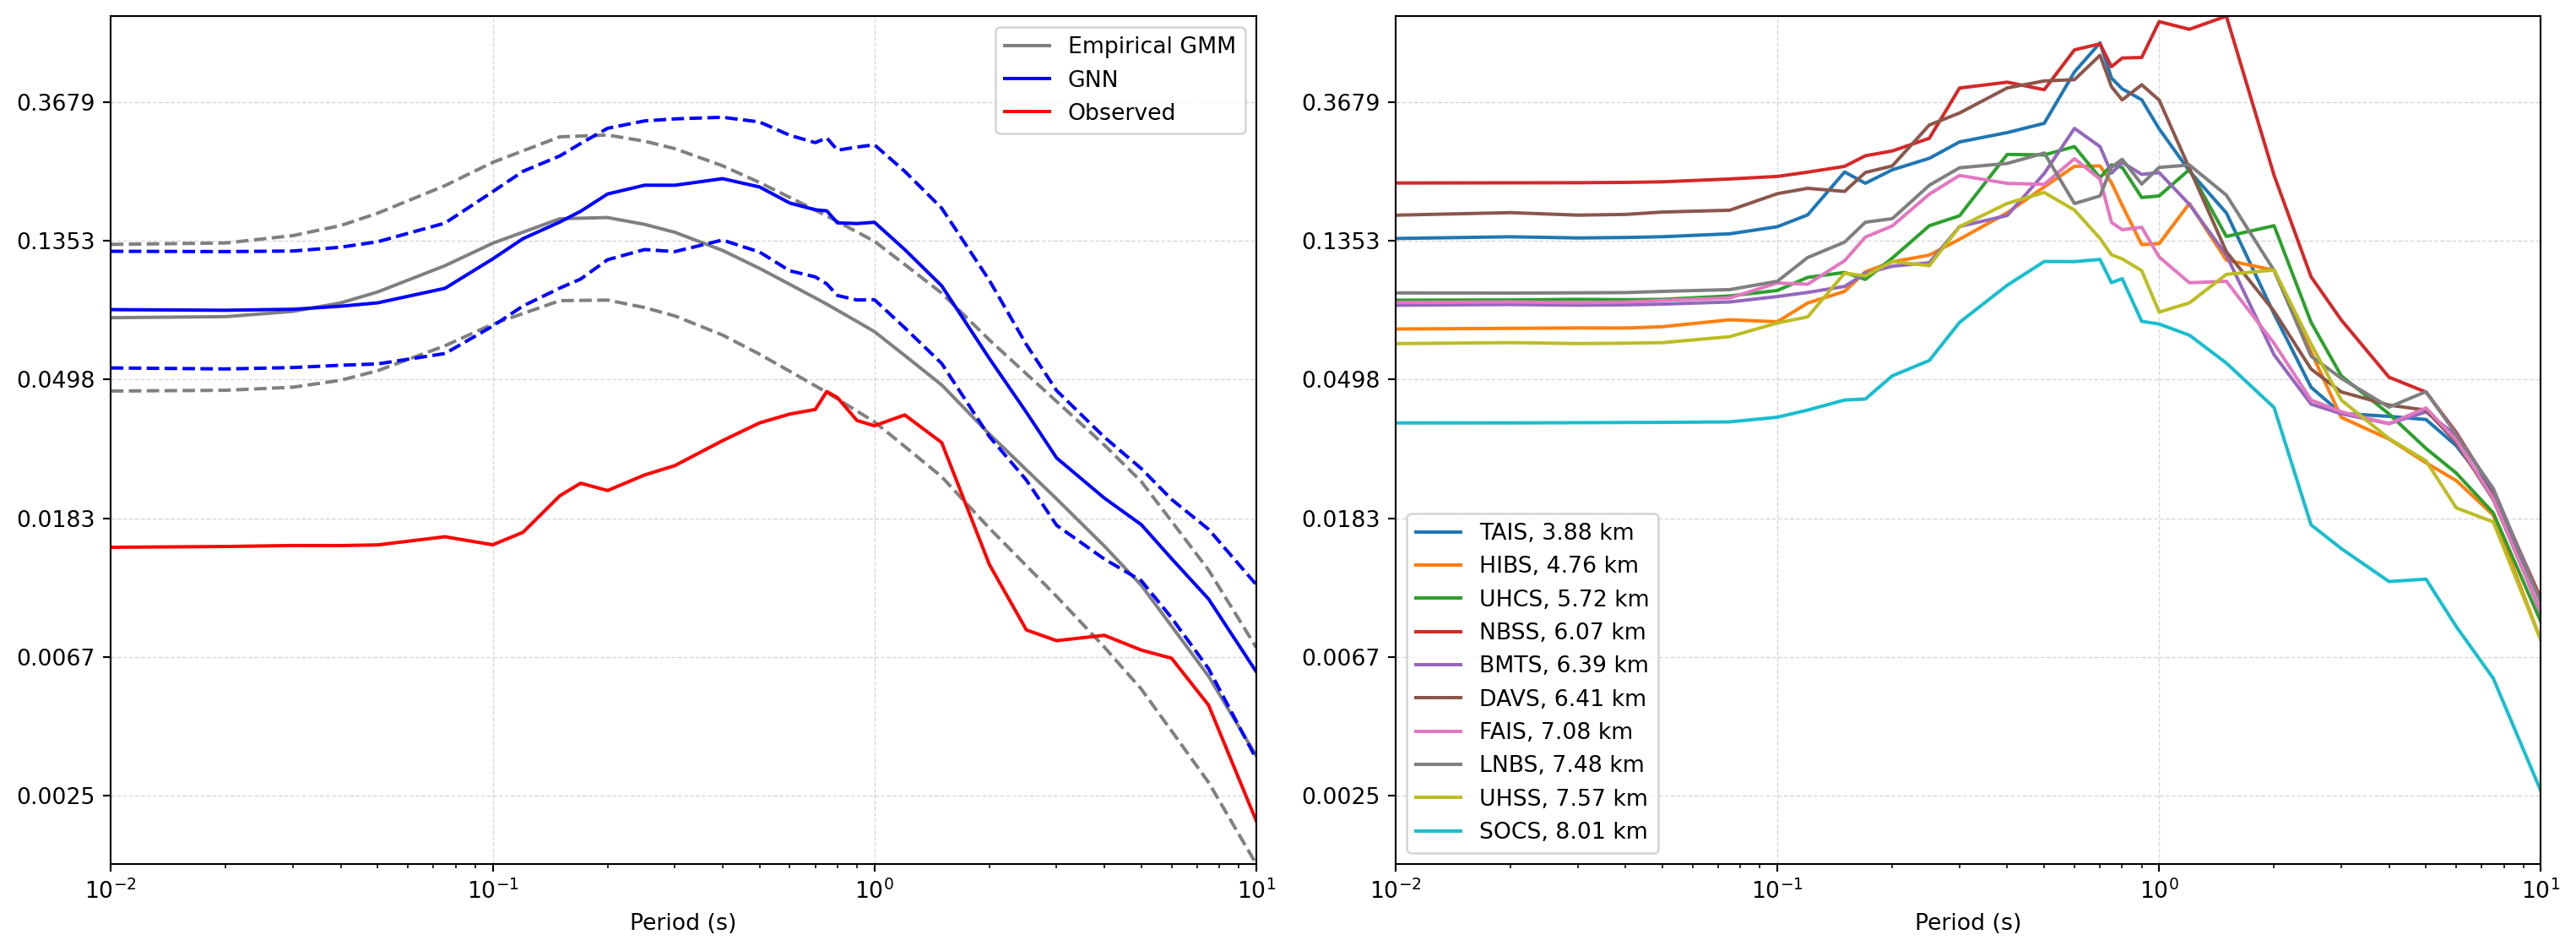

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
2016p858000_HSSS,88.878520,526.0,9.0,0.275,0.2200,0.000000
2016p858000_TAIS,85.004974,510.0,42.0,0.275,0.6900,3.877844
2016p858000_HIBS,92.780550,500.0,103.0,0.325,1.0000,4.755220
2016p858000_UHCS,94.173790,390.0,136.0,0.325,2.0000,5.715896
2016p858000_NBSS,83.046700,190.0,47.0,0.275,0.9000,6.065725
2016p858000_BMTS,82.564860,1000.0,15.0,0.275,0.0500,6.392335
2016p858000_DAVS,82.775420,300.0,35.0,0.275,0.6289,6.410827
2016p858000_FAIS,81.884190,1000.0,15.0,0.275,0.0500,7.081284
2016p858000_LNBS,81.394850,330.0,131.0,0.325,0.8000,7.483463
2016p858000_UHSS,95.504670,481.0,104.0,0.325,0.9000,7.565443


In [14]:
cur_event = "2016p858000"
cur_site = "HSSS"

# Plots
cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)
plt.show()

# Info
site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
display(site_info_df)

### 3528839 - HPSC

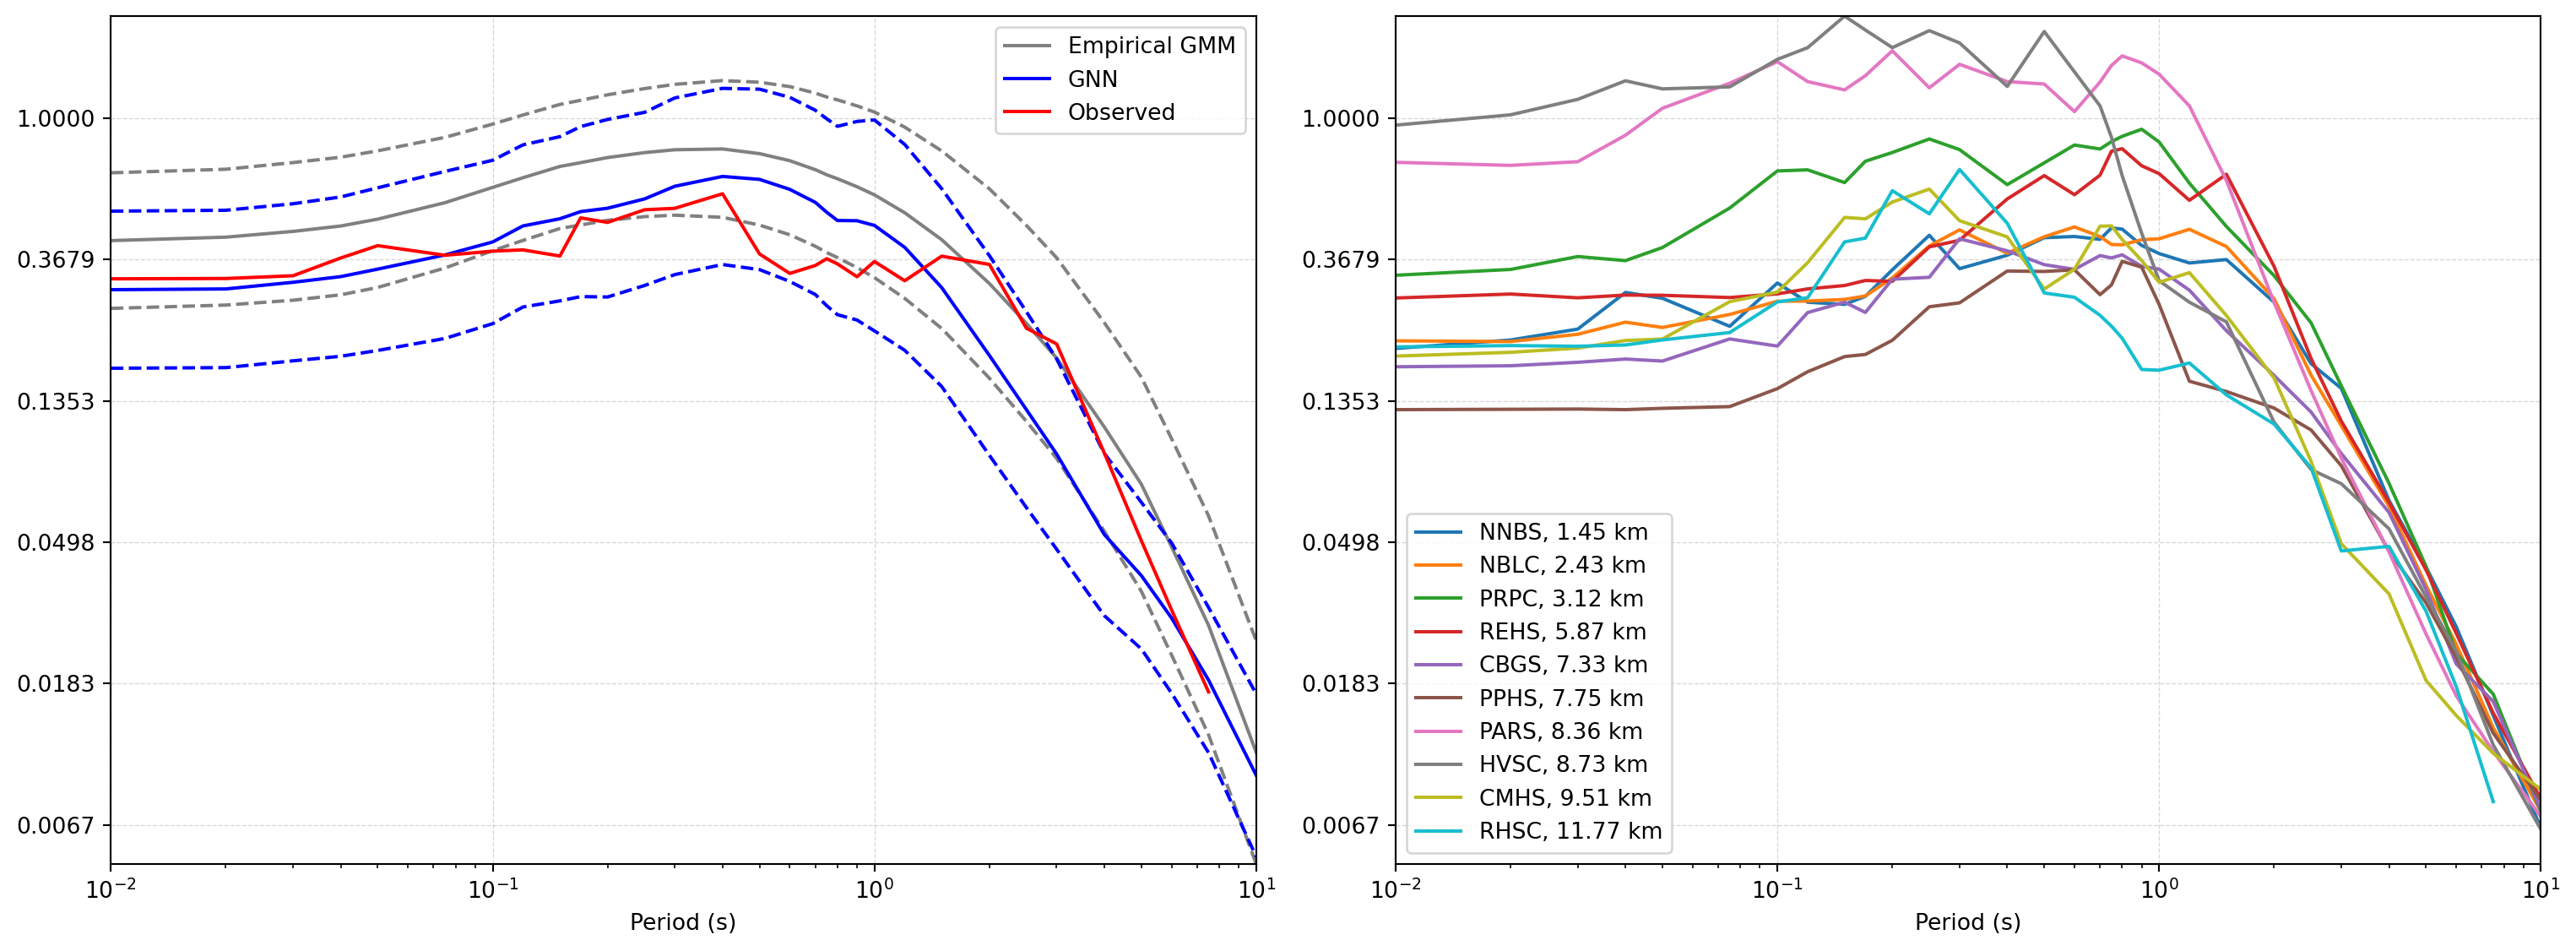

,rrup,vs30,z1p0,z2p5,tsite,site_int_distance
3528839_HPSC,2.742732,194.0,645.0,2.225,5.240,0.000000
3528839_NNBS,1.950122,204.0,685.0,2.175,4.870,1.448471
3528839_NBLC,0.793697,189.0,605.0,2.025,3.750,2.426769
3528839_PRPC,4.556602,196.0,485.0,2.075,5.280,3.120814
3528839_REHS,7.841723,155.0,645.0,2.575,4.990,5.868689
3528839_CBGS,9.120281,197.0,545.0,2.375,4.350,7.329462
3528839_PPHS,10.010922,180.0,665.0,3.325,6.200,7.754829
3528839_PARS,1.308622,750.0,58.0,1.775,0.050,8.357180
3528839_HVSC,4.466184,348.0,19.0,1.525,0.270,8.726144
3528839_CMHS,9.993749,213.0,125.0,1.625,0.695,9.511406


In [15]:
cur_event = "3528839"
cur_site = "HPSC"

# Plots
cur_obs_sites = get_obs_sites(cur_event, cur_site, gnn_val_results, dist_matrix, n_obs_sites=n_obs_sites)
# create_4plot(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix)
create_2plot_log(cur_event, cur_site, cur_obs_sites, gnn_val_results, cim_val_results, obs_data, dist_matrix, emp_gmm_params=emp_gmm_params)
plt.show()

# Info
site_info_df = get_site_info_df(cur_event, cur_site, cur_obs_sites, obs_data, dist_matrix)
display(site_info_df)